In [57]:
import os
import re
import csv
import numpy as np
import pandas as pd
from ase.io import read
import matplotlib.pyplot as plt

# Show float values with 2 decimal places when displaying DataFrames.
pd.options.display.float_format = '{:.2f}'.format

# Ensure wide DataFrames print all columns (no truncation).
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 20000)
pd.set_option('display.expand_frame_repr', True)

root = '/Users/jiuy97/Desktop/3_RuO2/6_ICOHP'
# oxygen_potential = -4.658724749999999 # 300K
# oxygen_potential = -4.658724749999999+0.27-0.73 # 700K
oxygen_potential = -4.658724749999999+0.27-0.85 # 800K
figsize = (4, 3)
dpi = 300

In [58]:
# import shutil
# import glob

# folder_to_remove = os.path.join(root, "4_slab_M-RuO2", "3_cus_O_O", "1_Hf")
# files = glob.glob(os.path.join(folder_to_remove, '*'))
# for f in files:
#     try:
#         if os.path.isfile(f) or os.path.islink(f):
#             os.remove(f)
#         elif os.path.isdir(f):
#             shutil.rmtree(f)
#     except Exception as e:
#         print(f"Failed to delete {f}. Reason: {e}")

In [59]:
data = pd.DataFrame(index=['Ru', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt'])
subdirs = ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os', '6_Ir', '7_Pt']

In [60]:
for dir in ['1_bulk_MO2', '2_bulk_MxOy', '3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        path = os.path.join(root, dir, subdir)
        energy_file = os.path.join(path, 'final_with_calculator.json')
        if os.path.exists(energy_file):
            atoms = read(energy_file)
            n_atoms = len(atoms)
            n_oxygens = sum(atom.symbol == 'O' for atom in atoms)
            n_metals = n_atoms - n_oxygens
            oxidation_state = 2 * n_oxygens / n_metals
            energy = atoms.get_potential_energy() / n_metals
            data.loc[element, f'{oxide_type}_energy'] = energy
            if oxide_type == 'MxOy':
                data.loc[element, f'{oxide_type}_os'] = oxidation_state

data['MO2_fe'] = (data['MO2_energy'] - (data['MxOy_energy'] + oxygen_potential * (2 - data['MxOy_os'] / 2)))/3
data['M-RuO2_fe'] = (data['M-RuO2_energy'] - 1/8*data['MxOy_energy'] - 7/8*(data['MxOy_energy']['Ru'] - 1/16*oxygen_potential*(4-data['MxOy_os']['Ru'])))/3
data['MxOy_fe'] = data['MxOy_energy']*0
# data.drop(columns=['MO2_energy', 'MxOy_energy', 'M-RuO2_energy'], inplace=True)
data


,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00


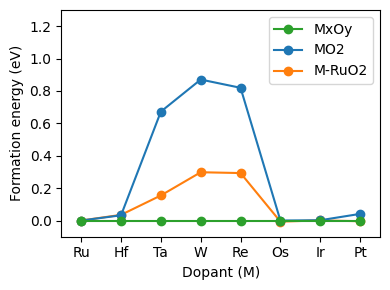

In [61]:
plt.figure(figsize=figsize)

cols = ['MxOy_fe', 'MO2_fe', 'M-RuO2_fe']
labels = ['MxOy', 'MO2', 'M-RuO2']
colors = ['tab:green', 'tab:blue', 'tab:orange']
zorders = [3, 2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('Formation energy (eV)')
plt.ylim(-0.1, 1.3)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_formation_energy.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

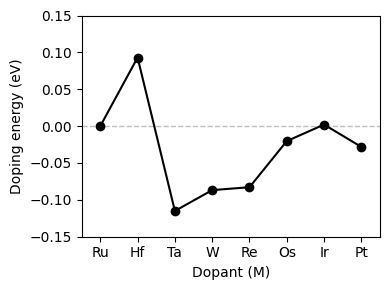

In [62]:
data['bulk_de'] = data['M-RuO2_energy'] - 1/8 * data['MO2_energy'] - 7/8 * data['MO2_energy']['Ru']

plt.figure(figsize=figsize)

plt.plot(
    data.index, 
    data['bulk_de'], 
    marker='o', 
    color='black', 
)

plt.axhline(0, color='silver', linestyle='--', linewidth='1', zorder=0)

plt.xlabel('Dopant (M)')
plt.ylabel('Doping energy (eV)')
plt.ylim(-0.15, 0.15)

plt.xlim(-0.5, 7.5)
# plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_doping_energy.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [63]:
for dir in ['1_bulk_MO2', '2_bulk_MxOy']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        path = os.path.join(root, dir, subdir)
        chg_file = os.path.join(path, 'atoms_bader_charge.json')
        if os.path.exists(chg_file):
            atoms = read(chg_file)
            chgs = atoms.get_initial_charges()
            metal_chgs = [chg for atom, chg in zip(atoms, chgs) if atom.symbol != 'O']
            chg_metal = sum(metal_chgs) / len(metal_chgs)
            data.loc[element, f'{oxide_type}_chg'] = chg_metal
        mag_file = os.path.join(path, 'moments.json')
        if os.path.exists(mag_file):
            atoms = read(mag_file)
            mags = atoms.get_magnetic_moments()
            metal_mags = [abs(mag) for atom, mag in zip(atoms, mags) if atom.symbol != 'O']
            mag_metal = sum(metal_mags) / len(metal_mags)
            data.loc[element, f'{oxide_type}_mag'] = mag_metal
data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00


In [64]:
for dir in ['3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        path = os.path.join(root, dir, subdir)
        atoms = read(os.path.join(path, 'final_with_calculator.json'))
        if element == 'Ru':
            M_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru']
            Ru_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru']
        else:
            M_index = [i for i, atom in enumerate(atoms) if atom.symbol != 'O' and atom.symbol != 'Ru']
            Ru_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru' and i != 4]
        
        chg_file = os.path.join(path, 'atoms_bader_charge.json')
        if os.path.exists(chg_file):
            atoms = read(chg_file)
            chgs = atoms.get_initial_charges()
            M_chg = sum(chgs[M_index])/len(M_index)
            Ru_chg = sum(chgs[Ru_index])/len(Ru_index)
            data.loc[element, f'{oxide_type}_chg(M)'] = M_chg
            data.loc[element, f'{oxide_type}_chg(Ru)'] = Ru_chg

        mag_file = os.path.join(path, 'moments.json')
        if os.path.exists(mag_file):
            atoms = read(mag_file)
            mags = atoms.get_magnetic_moments()
            M_mag = sum(abs(mags[i]) for i in M_index) / len(M_index)
            Ru_mag = sum(abs(mags[i]) for i in Ru_index) / len(Ru_index)
            data.loc[element, f'{oxide_type}_mag(M)'] = M_mag
            data.loc[element, f'{oxide_type}_mag(Ru)'] = Ru_mag
data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg(M),M-RuO2_chg(Ru),M-RuO2_mag(M),M-RuO2_mag(Ru)
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31


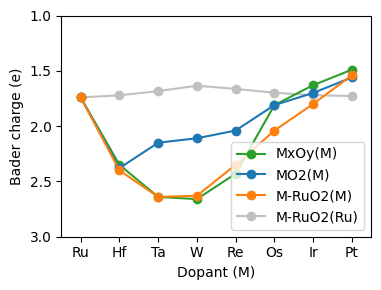

In [65]:
plt.figure(figsize=figsize)

cols = ['MxOy_chg', 'MO2_chg', 'M-RuO2_chg(M)', 'M-RuO2_chg(Ru)']
labels = ['MxOy(M)', 'MO2(M)', 'M-RuO2(M)', 'M-RuO2(Ru)']
colors = ['tab:green', 'tab:blue', 'tab:orange', 'silver']
zorders = [2, 3, 4, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            zorder=zorders[i % len(zorders)]
        )

# plt.title('MO2 vs M-RuO2')
plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (e)')
plt.ylim(3.0, 1.0)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_bader_charge.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [66]:
data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg(M),M-RuO2_chg(Ru),M-RuO2_mag(M),M-RuO2_mag(Ru)
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31


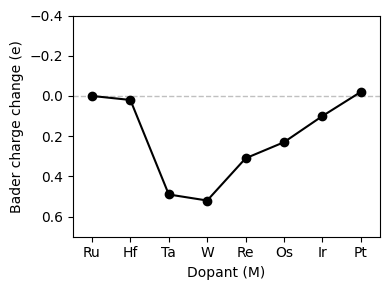

In [67]:
data['bulk_Δchg'] = data['M-RuO2_chg(M)'] - data['MO2_chg']

plt.figure(figsize=figsize)

plt.plot(
    data.index, 
    data['bulk_Δchg'], 
    marker='o', 
    color='black', 
)

plt.axhline(0, color='silver', linestyle='--', linewidth='1', zorder=0)

plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge change (e)')
plt.ylim(0.7, -0.4)

plt.xlim(-0.5, 7.5)
# plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_dopant_bader_charge.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

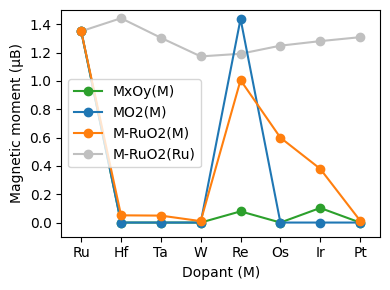

In [68]:
plt.figure(figsize=figsize)

cols = ['MxOy_mag', 'MO2_mag', 'M-RuO2_mag(M)', 'M-RuO2_mag(Ru)']
labels = ['MxOy(M)', 'MO2(M)', 'M-RuO2(M)', 'M-RuO2(Ru)']
colors = ['tab:green', 'tab:blue', 'tab:orange', 'silver']
zorders = [2, 3, 4, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            zorder=zorders[i % len(zorders)]
        )

# plt.title('MO2 vs M-RuO2')
plt.xlabel('Dopant (M)')
plt.ylabel('Magnetic moment (μB)')
plt.ylim(-0.1, 1.5)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_magnetic_moment.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [69]:
def parse_icohp_sum(icohp_file):
    total = 0.0
    with open(icohp_file, 'r') as file:
        for line in file:
            line = line.strip()
            if line:  # 빈 줄 무시
                total += float(line)
    return total

for dir in ['1_bulk_MO2', '2_bulk_MxOy', '3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        atoms = read(os.path.join(root, dir, 'cohp', subdir, 'final_with_calculator.json'))
        n_metal = len([atom for atom in atoms if atom.symbol != 'O'])

        icohp_all_file = os.path.join(root, dir, 'cohp', subdir, 'icohp_all.txt')
        icohp_spd_file = os.path.join(root, dir, 'cohp', subdir, 'icohp_spd.txt')

        if os.path.exists(icohp_all_file):
            icohp_all = parse_icohp_sum(icohp_all_file)
            if icohp_all is not None:
                data.loc[element, f'{oxide_type}_all_icohp'] = icohp_all / n_metal
        if os.path.exists(icohp_spd_file):
            icohp_spd = parse_icohp_sum(icohp_spd_file)
            if icohp_spd is not None:
                data.loc[element, f'{oxide_type}_spd_icohp'] = icohp_spd / n_metal

        if dir == '3_bulk_M-RuO2':

            icohp_all_dopant_file = os.path.join(root, dir, 'cohp', subdir, 'icohp_all_dopant.txt')
            icohp_spd_dopant_file = os.path.join(root, dir, 'cohp', subdir, 'icohp_spd_dopant.txt')

            if os.path.exists(icohp_all_dopant_file):
                icohp_all_dopant = parse_icohp_sum(icohp_all_dopant_file)
                if icohp_all_dopant is not None:
                    data.loc[element, f'{oxide_type}_all_icohp(M)'] = icohp_all_dopant

            if os.path.exists(icohp_spd_dopant_file):
                icohp_spd_dopant = parse_icohp_sum(icohp_spd_dopant_file)
                if icohp_spd_dopant is not None:
                    data.loc[element, f'{oxide_type}_spd_icohp(M)'] = icohp_spd_dopant


data.loc['Ru', 'M-RuO2_all_icohp(M)'] = data.loc['Ru', 'M-RuO2_all_icohp']
data.loc['Ru', 'M-RuO2_spd_icohp(M)'] = data.loc['Ru', 'M-RuO2_spd_icohp']
data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg(M),M-RuO2_chg(Ru),M-RuO2_mag(M),M-RuO2_mag(Ru),bulk_Δchg,MO2_all_icohp,MO2_spd_icohp,MxOy_all_icohp,MxOy_spd_icohp,M-RuO2_all_icohp,M-RuO2_spd_icohp,M-RuO2_all_icohp(M),M-RuO2_spd_icohp(M)
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,0.00,-19.87,-11.90,-19.87,-11.90,-19.94,-11.94,-19.94,-11.94
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,0.02,-25.45,-14.98,-25.53,-15.30,-20.37,-12.12,-24.83,-15.32
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,0.49,-24.85,-15.08,-29.58,-17.99,-20.61,-12.35,-27.82,-18.41
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,0.52,-24.29,-14.98,-33.87,-20.99,-20.64,-12.42,-29.36,-20.23
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,0.31,-22.67,-14.11,-32.21,-20.05,-20.44,-12.33,-25.32,-17.91
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25,0.23,-22.16,-13.90,-22.16,-13.90,-20.25,-12.22,-22.39,-16.02
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28,0.10,-20.10,-12.46,-19.04,-12.52,-19.96,-12.02,-18.38,-13.50
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31,-0.02,-17.01,-10.61,-15.74,-10.82,-19.61,-11.77,-15.07,-11.23


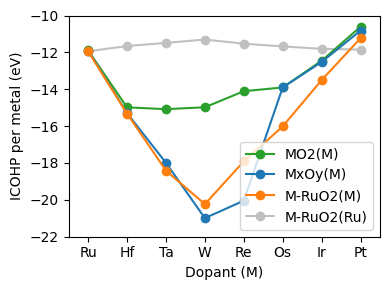

In [70]:
data['M-RuO2_all_icohp(Ru)'] = (data['M-RuO2_all_icohp'] * 8 - data['M-RuO2_all_icohp(M)']) / 7
data['M-RuO2_spd_icohp(Ru)'] = (data['M-RuO2_spd_icohp'] * 8 - data['M-RuO2_spd_icohp(M)']) / 7

plt.figure(figsize=figsize)

cols = ['MO2_spd_icohp', 'MxOy_spd_icohp', 'M-RuO2_spd_icohp(M)', 'M-RuO2_spd_icohp(Ru)']
labels = ['MO2(M)', 'MxOy(M)', 'M-RuO2(M)', 'M-RuO2(Ru)']
colors = ['tab:green', 'tab:blue', 'tab:orange', 'silver']
zorders = [2, 3, 4, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('ICOHP per metal (eV)')
plt.ylim(-22, -10)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_spd_icohp_per_metal.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

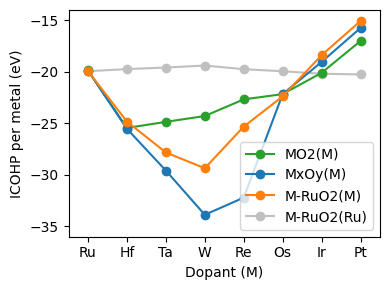

In [71]:
plt.figure(figsize=figsize)

cols = ['MO2_all_icohp', 'MxOy_all_icohp', 'M-RuO2_all_icohp(M)', 'M-RuO2_all_icohp(Ru)']
labels = ['MO2(M)', 'MxOy(M)', 'M-RuO2(M)', 'M-RuO2(Ru)']
colors = ['tab:green', 'tab:blue', 'tab:orange', 'silver']
zorders = [2, 3, 4, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('ICOHP per metal (eV)')
plt.ylim(-36, -14)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_all_icohp_per_metal.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

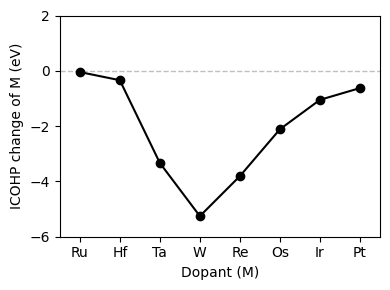

In [72]:
data['bulk_Δicohp_spd'] = data['M-RuO2_spd_icohp(M)'] - data['MO2_spd_icohp']
data['bulk_Δicohp_all'] = data['M-RuO2_all_icohp(M)'] - data['MO2_all_icohp']

plt.figure(figsize=figsize)

plt.plot(
    data.index, 
    data['bulk_Δicohp_spd'], 
    marker='o', 
    color='black', 
)

plt.axhline(0, color='silver', linestyle='--', linewidth='1', zorder=0)

plt.xlabel('Dopant (M)')
plt.ylabel('ICOHP change of M (eV)')
plt.ylim(-6, 2)

plt.xlim(-0.5, 7.5)
# plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_dopant_spd_icohp.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

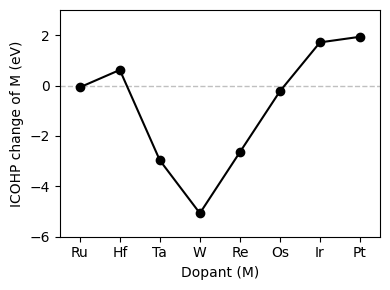

In [73]:
plt.figure(figsize=figsize)

plt.plot(
    data.index, 
    data['bulk_Δicohp_all'], 
    marker='o', 
    color='black', 
)

plt.axhline(0, color='silver', linestyle='--', linewidth='1', zorder=0)

plt.xlabel('Dopant (M)')
plt.ylabel('ICOHP change of M (eV)')
plt.ylim(-6, 3)

plt.xlim(-0.5, 7.5)
# plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
plt.savefig(f'{root}/figures/bulk_dopant_all_icohp.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [74]:
for coverage in ['V', 'O']:
    if coverage == 'V':
        RuO2_path = os.path.join(root, '4_slab_M-RuO2', '1_cus_V_V', '0_Ru')
        dirs = ['1_cus_V_V', '2_brg_V_V']
    elif coverage == 'O':
        RuO2_path = os.path.join(root, '4_slab_M-RuO2', '3_cus_O_O', '0_Ru')
        dirs = ['3_cus_O_O', '4_brg_O_O']

    RuO2_atoms = read(os.path.join(RuO2_path, 'final_with_calculator.json'))
    RuO2_energy = RuO2_atoms.get_potential_energy()

    for dir in dirs:
        ads_site = dir.split('_')[1]

        for subdir in subdirs:
            element = subdir.split('_')[1]
            path = os.path.join(root, '4_slab_M-RuO2', dir, subdir)
            energy_file = os.path.join(path, 'final_with_calculator.json')
            if os.path.exists(energy_file):
                atoms = read(energy_file)
                energy = atoms.get_potential_energy()
                
                # doping_energy_MxOy = (energy - data['MxOy_energy'][element] + oxygen_potential * data['MxOy_os'][element] / 2) \
                #     - (RuO2_energy - data['MxOy_energy']['Ru'] + oxygen_potential * data['MxOy_os']['Ru'] / 2)
                # data.loc[element, f'{ads_site}_{coverage}_de_MxOy'] = doping_energy_MxOy

                doping_energy_MO2 = (energy - data['MO2_energy'][element]) - (RuO2_energy - data['MO2_energy']['Ru'])
                # data.loc[element, f'{ads_site}_{coverage}_de_MO2'] = doping_energy_MO2
                data.loc[element, f'{ads_site}_{coverage}_de'] = doping_energy_MO2

            chg_file = os.path.join(path, 'atoms_bader_charge.json')
            if element == 'Ru' and ads_site == 'brg':
                M_index = 13
            else:
                M_index = 15
            if os.path.exists(chg_file):
                atoms = read(chg_file)
                M_chg = atoms.get_initial_charges()[M_index]
                data.loc[element, f'{ads_site}_{coverage}_chg'] = M_chg
                
data


,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg(M),M-RuO2_chg(Ru),M-RuO2_mag(M),M-RuO2_mag(Ru),bulk_Δchg,MO2_all_icohp,MO2_spd_icohp,MxOy_all_icohp,MxOy_spd_icohp,M-RuO2_all_icohp,M-RuO2_spd_icohp,M-RuO2_all_icohp(M),M-RuO2_spd_icohp(M),M-RuO2_all_icohp(Ru),M-RuO2_spd_icohp(Ru),bulk_Δicohp_spd,bulk_Δicohp_all,cus_V_de,cus_V_chg,brg_V_de,brg_V_chg,cus_O_de,cus_O_chg,brg_O_de,brg_O_chg
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,0.00,-19.87,-11.90,-19.87,-11.90,-19.94,-11.94,-19.94,-11.94,-19.94,-11.94,-0.04,-0.07,0.00,1.68,0.00,1.76,0.00,1.83,0.00,1.80
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,0.02,-25.45,-14.98,-25.53,-15.30,-20.37,-12.12,-24.83,-15.32,-19.73,-11.66,-0.34,0.62,0.40,2.38,0.30,2.26,7.00,2.35,0.55,2.33
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,0.49,-24.85,-15.08,-29.58,-17.99,-20.61,-12.35,-27.82,-18.41,-19.58,-11.49,-3.33,-2.97,-1.09,2.64,-1.79,2.67,-1.22,2.55,-1.73,2.56
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,0.52,-24.29,-14.98,-33.87,-20.99,-20.64,-12.42,-29.36,-20.23,-19.39,-11.31,-5.26,-5.07,-0.62,2.62,-2.03,2.61,-1.70,2.72,-2.11,2.63
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,0.31,-22.67,-14.11,-32.21,-20.05,-20.44,-12.33,-25.32,-17.91,-19.74,-11.53,-3.81,-2.64,-0.43,2.32,-1.68,2.45,-1.82,2.33,-2.00,2.55
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25,0.23,-22.16,-13.90,-22.16,-13.90,-20.25,-12.22,-22.39,-16.02,-19.95,-11.68,-2.11,-0.22,0.19,1.93,-0.54,2.16,-1.03,2.19,-0.55,2.11
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28,0.10,-20.10,-12.46,-19.04,-12.52,-19.96,-12.02,-18.38,-13.50,-20.18,-11.81,-1.05,1.71,0.41,1.58,-0.11,1.70,0.00,1.89,0.08,1.76
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31,-0.02,-17.01,-10.61,-15.74,-10.82,-19.61,-11.77,-15.07,-11.23,-20.26,-11.85,-0.62,1.94,-0.26,1.21,-0.55,1.50,0.57,1.68,-0.27,1.58


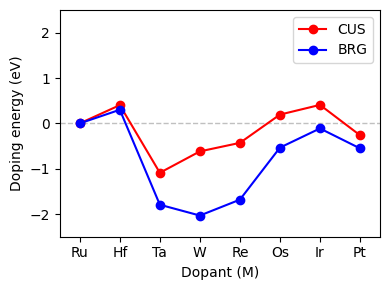

In [86]:
plt.figure(figsize=figsize)

cols = ['cus_V_de', 'brg_V_de']
labels = ['CUS', 'BRG']
colors = ['red', 'blue']
zorders = [2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )
plt.axhline(0, color='silver', linestyle='--', linewidth='1', zorder=0)

plt.xlabel('Dopant (M)')
plt.ylabel('Doping energy (eV)')
plt.ylim(-2.5, 2.5)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_doping_energy.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

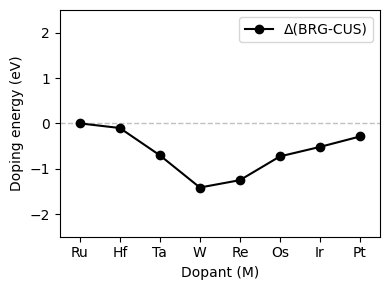

In [76]:
data['O_Δde'] = data['brg_O_de'] - data['cus_O_de']
data['V_Δde'] = data['brg_V_de'] - data['cus_V_de']

plt.figure(figsize=figsize)

plt.plot(
    data.index, 
    data['V_Δde'], 
    marker='o', 
    label='Δ(BRG-CUS)', 
    color='black', 
)

plt.axhline(0, color='silver', linestyle='--', linewidth='1', zorder=0)

plt.xlabel('Dopant (M)')
plt.ylabel('Doping energy (eV)')
plt.ylim(-2.5, 2.5)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_site_preference.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

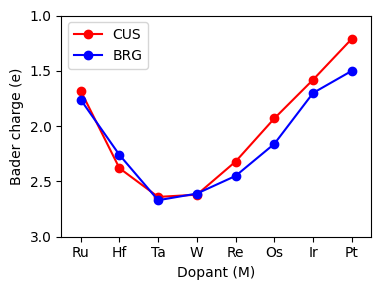

In [77]:
plt.figure(figsize=figsize)

cols = ['cus_V_chg', 'brg_V_chg']
labels = ['CUS', 'BRG']
colors = ['red', 'blue']
zorders = [2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (e)')
plt.ylim(3.0, 1.0)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_bader_charge.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

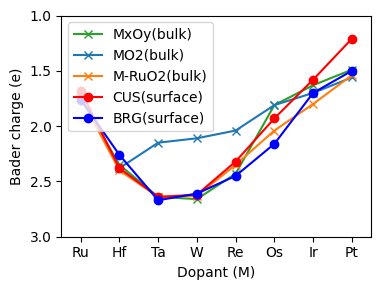

In [78]:
plt.figure(figsize=figsize)

cols = ['MxOy_chg', 'MO2_chg', 'M-RuO2_chg(M)', 'cus_V_chg', 'brg_V_chg']
labels = ['MxOy(bulk)', 'MO2(bulk)', 'M-RuO2(bulk)', 'CUS(surface)', 'BRG(surface)']
colors = ['tab:green', 'tab:blue', 'tab:orange', 'red', 'blue']
zorders = [2, 1, 3, 4, 5]

for i, col in enumerate(cols):
    label=labels[i % len(labels)]
    if 'bulk' in label:
        marker = 'x'
    else:
        marker = 'o'
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker=marker, 
            label=label, 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (e)')
plt.ylim(3.0, 1.0)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/all_bader_charge.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

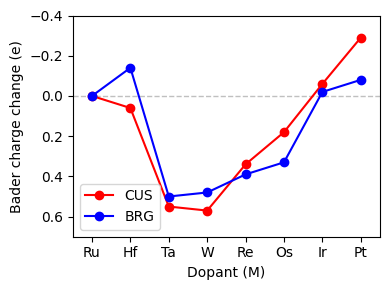

In [85]:
data['cus_V_Δchg'] = data['cus_V_chg'] - data['cus_V_chg']['Ru'] - data['MO2_chg'] + data['MO2_chg']['Ru']
data['brg_V_Δchg'] = data['brg_V_chg'] - data['brg_V_chg']['Ru'] - data['MO2_chg'] + data['MO2_chg']['Ru']

plt.figure(figsize=figsize)

cols = ['cus_V_Δchg', 'brg_V_Δchg']
labels = ['CUS', 'BRG']
colors = ['red', 'blue']
zorders = [2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )
plt.axhline(0, color='silver', linestyle='--', linewidth='1', zorder=0)

plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge change (e)')
plt.ylim(0.7, -0.4)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_dopant_bader_charge.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [80]:
for dir in ['1_cus_V_V', '2_brg_V_V', '3_cus_O_O', '4_brg_O_O']:
    ads_site = dir.split('_')[1]
    coverage = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        spd_icohp_file = os.path.join(root, '4_slab_M-RuO2', 'cohp', dir, subdir, 'icohp_spd.txt')
        all_icohp_file = os.path.join(root, '4_slab_M-RuO2', 'cohp', dir, subdir, 'icohp_all.txt')

        if os.path.exists(spd_icohp_file):
            spd_icohp_sum = parse_icohp_sum(spd_icohp_file)
            if spd_icohp_sum is not None:
                data.loc[element, f'{ads_site}_{coverage}_spd_icohp'] = spd_icohp_sum
        if os.path.exists(all_icohp_file):
            all_icohp_sum = parse_icohp_sum(all_icohp_file)
            if all_icohp_sum is not None:
                data.loc[element, f'{ads_site}_{coverage}_all_icohp'] = all_icohp_sum

data[['cus_V_all_icohp', 'brg_V_all_icohp', 'cus_V_spd_icohp', 'brg_V_spd_icohp']]

,cus_V_all_icohp,brg_V_all_icohp,cus_V_spd_icohp,brg_V_spd_icohp
Ru,-14.60,-17.51,-10.64,-12.34
Hf,-21.39,-23.01,-13.50,-14.01
Ta,-25.35,-26.64,-17.27,-17.88
W,-26.63,-28.97,-18.89,-20.39
Re,NaN,NaN,NaN,NaN
Os,-18.93,-22.45,-14.08,-16.34
Ir,-14.93,-17.46,-11.56,-12.86
Pt,-10.74,-14.22,-8.71,-10.57


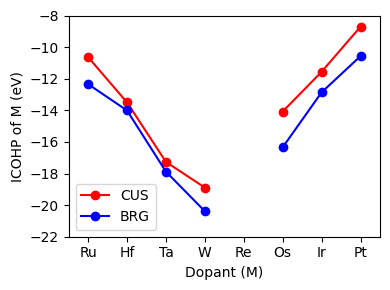

In [81]:
plt.figure(figsize=figsize)

cols = ['cus_V_spd_icohp', 'brg_V_spd_icohp']
labels = ['CUS', 'BRG']
colors = ['red', 'blue']
zorders = [2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('ICOHP of M (eV)')
plt.ylim(-22, -8)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_spd_icohp_per_metal.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

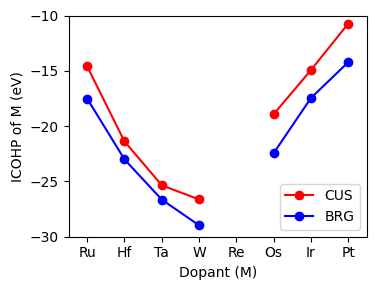

In [82]:
plt.figure(figsize=figsize)

cols = ['cus_V_all_icohp', 'brg_V_all_icohp']
labels = ['CUS', 'BRG']
colors = ['red', 'blue']
zorders = [2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )

plt.xlabel('Dopant (M)')
plt.ylabel('ICOHP of M (eV)')
plt.ylim(-30, -10)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_all_icohp_per_metal.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

In [83]:
data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MxOy_fe,bulk_de,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg(M),M-RuO2_chg(Ru),M-RuO2_mag(M),M-RuO2_mag(Ru),bulk_Δchg,MO2_all_icohp,MO2_spd_icohp,MxOy_all_icohp,MxOy_spd_icohp,M-RuO2_all_icohp,M-RuO2_spd_icohp,M-RuO2_all_icohp(M),M-RuO2_spd_icohp(M),M-RuO2_all_icohp(Ru),M-RuO2_spd_icohp(Ru),bulk_Δicohp_spd,bulk_Δicohp_all,cus_V_de,cus_V_chg,brg_V_de,brg_V_chg,cus_O_de,cus_O_chg,brg_O_de,brg_O_chg,O_Δde,V_Δde,cus_V_Δchg,brg_V_Δchg,cus_V_spd_icohp,cus_V_all_icohp,brg_V_spd_icohp,brg_V_all_icohp,cus_O_spd_icohp,cus_O_all_icohp,brg_O_spd_icohp,brg_O_all_icohp
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,-0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,0.00,-19.87,-11.90,-19.87,-11.90,-19.94,-11.94,-19.94,-11.94,-19.94,-11.94,-0.04,-0.07,0.00,1.68,0.00,1.76,0.00,1.83,0.00,1.80,0.00,0.00,0.00,0.00,-10.64,-14.60,-12.34,-17.51,-12.36,-17.58,-12.36,-17.57
Hf,-30.48,-30.58,4.00,-21.16,0.03,0.04,-0.00,0.09,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,0.02,-25.45,-14.98,-25.53,-15.30,-20.37,-12.12,-24.83,-15.32,-19.73,-11.66,-0.34,0.62,0.40,2.38,0.30,2.26,7.00,2.35,0.55,2.33,-6.45,-0.10,0.06,-0.14,-13.50,-21.39,-14.01,-23.01,-14.08,-23.08,-14.46,-23.51
Ta,-29.51,-34.15,5.00,-21.25,0.67,0.15,-0.00,-0.12,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,0.49,-24.85,-15.08,-29.58,-17.99,-20.61,-12.35,-27.82,-18.41,-19.58,-11.49,-3.33,-2.97,-1.09,2.64,-1.79,2.67,-1.22,2.55,-1.73,2.56,-0.51,-0.70,0.55,0.50,-17.27,-25.35,-17.88,-26.64,-17.97,-26.61,-18.03,-26.86
W,-28.49,-36.34,6.00,-21.09,0.87,0.30,-0.00,-0.09,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,0.52,-24.29,-14.98,-33.87,-20.99,-20.64,-12.42,-29.36,-20.23,-19.39,-11.31,-5.26,-5.07,-0.62,2.62,-2.03,2.61,-1.70,2.72,-2.11,2.63,-0.41,-1.42,0.57,0.48,-18.89,-26.63,-20.39,-28.97,-20.43,-29.03,-20.50,-29.16
Re,-25.90,-33.59,6.00,-20.76,0.82,0.29,-0.00,-0.08,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,0.31,-22.67,-14.11,-32.21,-20.05,-20.44,-12.33,-25.32,-17.91,-19.74,-11.53,-3.81,-2.64,-0.43,2.32,-1.68,2.45,-1.82,2.33,-2.00,2.55,-0.18,-1.25,0.34,0.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Os,-23.78,-23.78,4.00,-20.44,0.00,-0.01,-0.00,-0.02,1.81,0.00,1.81,0.00,2.04,1.70,0.60,1.25,0.23,-22.16,-13.90,-22.16,-13.90,-20.25,-12.22,-22.39,-16.02,-19.95,-11.68,-2.11,-0.22,0.19,1.93,-0.54,2.16,-1.03,2.19,-0.55,2.11,0.48,-0.73,0.18,0.33,-14.08,-18.93,-16.34,-22.45,-18.34,-25.14,-17.12,-23.70
Ir,-21.12,-21.13,4.00,-20.08,0.00,0.00,-0.00,0.00,1.70,0.00,1.63,0.10,1.80,1.72,0.38,1.28,0.10,-20.10,-12.46,-19.04,-12.52,-19.96,-12.02,-18.38,-13.50,-20.18,-11.81,-1.05,1.71,0.41,1.58,-0.11,1.70,0.00,1.89,0.08,1.76,0.08,-0.52,-0.06,-0.02,-11.56,-14.93,-12.86,-17.46,-14.91,-20.16,-13.16,-17.91
Pt,-17.38,-17.50,4.00,-19.64,0.04,-0.00,-0.00,-0.03,1.56,0.00,1.49,0.00,1.54,1.73,0.01,1.31,-0.02,-17.01,-10.61,-15.74,-10.82,-19.61,-11.77,-15.07,-11.23,-20.26,-11.85,-0.62,1.94,-0.26,1.21,-0.55,1.50,0.57,1.68,-0.27,1.58,-0.84,-0.29,-0.29,-0.08,-8.71,-10.74,-10.57,-14.22,-12.01,-16.26,-11.06,-14.83


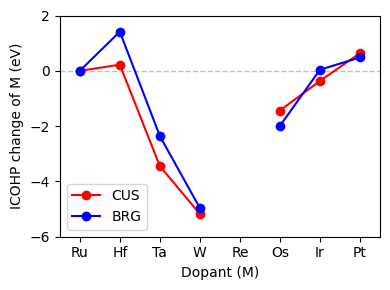

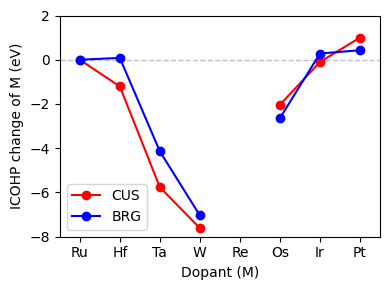

In [84]:
data['cus_V_Δicohp_spd'] = data['cus_V_spd_icohp'] - data['cus_V_spd_icohp']['Ru'] - data['MO2_spd_icohp'] + data['MO2_spd_icohp']['Ru']
data['brg_V_Δicohp_spd'] = data['brg_V_spd_icohp'] - data['brg_V_spd_icohp']['Ru'] - data['MO2_spd_icohp'] + data['MO2_spd_icohp']['Ru']
data['cus_V_Δicohp_all'] = data['cus_V_all_icohp'] - data['cus_V_all_icohp']['Ru'] - data['MO2_all_icohp'] + data['MO2_all_icohp']['Ru']
data['brg_V_Δicohp_all'] = data['brg_V_all_icohp'] - data['brg_V_all_icohp']['Ru'] - data['MO2_all_icohp'] + data['MO2_all_icohp']['Ru']

plt.figure(figsize=figsize)

cols = ['cus_V_Δicohp_spd', 'brg_V_Δicohp_spd']
labels = ['CUS', 'BRG']
colors = ['red', 'blue']
zorders = [2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )
plt.axhline(0, color='silver', linestyle='--', linewidth='1', zorder=0)

plt.xlabel('Dopant (M)')
plt.ylabel('ICOHP change of M (eV)')
plt.ylim(-6, 2)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_dopant_spd_icohp_change.png', dpi=dpi, transparent=True)
plt.show()
plt.close()

plt.figure(figsize=figsize)

cols = ['cus_V_Δicohp_all', 'brg_V_Δicohp_all']
labels = ['CUS', 'BRG']
colors = ['red', 'blue']
zorders = [2, 1]

for i, col in enumerate(cols):
    if col in data.columns:
        plt.plot(
            data.index, 
            data[col], 
            marker='o', 
            label=labels[i % len(labels)], 
            color=colors[i % len(colors)], 
            # zorder=zorders[i % len(zorders)]
        )
plt.axhline(0, color='silver', linestyle='--', linewidth='1', zorder=0)

plt.xlabel('Dopant (M)')
plt.ylabel('ICOHP change of M (eV)')
plt.ylim(-8, 2)

plt.xlim(-0.5, 7.5)
plt.legend(loc='best')
plt.xticks(range(len(data.index)), data.index.tolist())

plt.tight_layout()
# coverage = coverage.split('_')[0]
plt.savefig(f'{root}/figures/surface_dopant_all_icohp_change.png', dpi=dpi, transparent=True)
plt.show()
plt.close()